In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read the data
data = pd.read_excel("data.xlsx").drop('SerialNo', axis=1)

In [31]:
# Here I obtain the vocabulary and documents in data structures
vocabulary = {}
documents = []
for index, row in data.iterrows():
    document = row['Session_Summary'].strip().split()
    documents.append(document)
    for word in document:
        word = word.strip()
        if word not in vocabulary:
            vocabulary[word] = 0
        vocabulary[word] += 1
num_documents = len(documents)
num_words = len(vocabulary)
print("Unique words: ",num_words)
for word, freq in vocabulary.items():
    print(word, freq)

Unique words:  10451
we 4088
started 233
our 387
lecture 114
with 997
a 2530
recap 20
of 4076
previous 42
particularly 22
about 650
the 8507
difference 93
between 371
statistically 89
similar 61
values 425
and 4000
significant 55
values. 94
then 899
new 79
topic 28
called 142
as 970
multiple 332
linear 529
regression. 138
name 6
suggests, 2
it 976
is 2619
regression 661
but 336
dependent 114
upon 59
features. 94
looked 108
how 653
things 31
like 449
sales 14
depend 7
on 948
factors 21
age, 4
earning, 3
family 4
size 98
etc. 86
which 1080
y 248
are 1005
known 94
goal 33
to 3300
represent 55
combination 60
x1, 11
x2, 7
x3, 4
..., 2
xn. 1
suppose 14
= 230
b0 49
+ 133
b1x1 4
b2x2 5
...... 2
objective 13
find 155
b0, 2
b1, 3
b2 1
do 156
by 703
method 156
gradient 67
descent 56
numerical 43
very 138
newton 5
raphson 4
method, 24
used 407
for 1386
n 30
dimensions. 17
prof 4
showed 36
an 330
illustration 1
excel 84
where 395
was 461
5 16
performed 27
mlr 82
had 83
look 35
at 329
p-values 21
ca

In [4]:
# create an index for each word
index_to_word = {}
word_to_index = {}
for i, word in enumerate(vocabulary):
    index_to_word[i] = word
    word_to_index[word] = i

# convert documents to just word indices
numerical_documents = []
for document in documents:
    numerical_documents.append([word_to_index[word] for word in document])

for document in numerical_documents:
    print(document)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 3, 9, 10, 11, 12, 13, 14, 15, 16, 17, 14, 18, 19, 0, 20, 1, 5, 21, 22, 23, 24, 25, 26, 27, 24, 11, 28, 29, 30, 31, 5, 26, 32, 33, 34, 35, 25, 36, 0, 37, 38, 39, 40, 41, 42, 43, 25, 44, 40, 45, 46, 47, 48, 49, 11, 39, 43, 50, 2, 51, 31, 34, 52, 53, 24, 36, 2, 54, 31, 55, 56, 51, 24, 5, 26, 57, 7, 58, 59, 60, 61, 62, 63, 51, 64, 65, 66, 67, 66, 68, 66, 69, 2, 70, 31, 55, 71, 11, 16, 7, 72, 73, 74, 50, 0, 75, 76, 5, 77, 23, 24, 78, 79, 50, 31, 5, 80, 77, 81, 15, 55, 82, 83, 84, 33, 85, 86, 87, 88, 89, 20, 90, 91, 92, 43, 93, 94, 11, 51, 95, 34, 43, 96, 36, 0, 97, 98, 17, 99, 5, 100, 101, 11, 102, 7, 11, 103, 104, 105, 106, 99, 5, 107, 108, 109, 110, 111, 11, 112, 50, 113, 114, 11, 115, 7, 116, 117, 118, 31, 81, 119, 0, 20, 1, 120, 11, 121, 122, 76, 122, 50, 99, 11, 123, 124, 125, 126, 31, 5, 127, 53, 24, 128, 129, 94, 128, 64, 130, 131, 128, 132, 55, 133, 134, 24, 0, 135, 11, 136, 128, 129, 1, 55, 137]
[138, 139, 140, 0, 141, 142, 143, 144, 145, 146, 86, 147, 1

In [5]:
# calculate the IDFs
IDFs = {}
for i in index_to_word:
    count = 0
    for document in numerical_documents:
        if i in document:
            count += 1
    IDFs[i] = np.log(num_documents/count)

print(IDFs)

{0: 0.1763513898074508, 1: 1.283932348458321, 2: 1.2731795566820592, 3: 2.085447565740048, 4: 0.3687232824549068, 5: 0.15865181270804996, 6: 3.5085558999826545, 7: 0.0665365238002442, 8: 2.893370260892421, 9: 3.6139164156404813, 10: 0.7082304227712738, 11: 0.04125871661597564, 12: 2.1735548332503147, 13: 0.9868352770719381, 14: 2.6330871626287546, 15: 2.697625683766326, 16: 1.133650145408983, 17: 0.0150832422113285, 18: 2.5922651681085, 19: 2.186800060000335, 20: 0.6098853392717949, 21: 2.3934143093633344, 22: 3.2084513075323167, 23: 1.812940291307502, 24: 0.493020999132484, 25: 1.124390819996186, 26: 0.7938611561617762, 27: 1.7167964307545998, 28: 4.712528704308591, 29: 5.811140992976701, 30: 0.48813101383829216, 31: 0.23519188983038425, 32: 0.6492162513342186, 33: 1.0926421216816058, 34: 1.9824995964876055, 35: 2.6330871626287546, 36: 2.2276220545205905, 37: 2.2276220545205905, 38: 0.6463550190531864, 39: 3.172083663361442, 40: 0.894816378351686, 41: 4.106392900738276, 42: 4.55837802

['f', 'had', '+', 'features.', 'xn.', 'b2', 'illustration', 'things', 'y', 'dependent', 'suggests,', '...,', '......', 'b0,', 'earning,', 'b1,', 'corresponds', 'similar', 'statistically', 'started', 'age,', 'family', 'x3,', 'b1x1', 'raphson', 'prof', 'msr/mse.', 'increase.', 'our', 'b2x2', 'newton', 'name', 'x2,', 'low.', 'depend', 'known', 'except', 'coefficients.', 'lecture', 'sales', 'x1,', 'suppose', 'dropped', 'objective', 'p-value.', 'intercept', 'very', '5', 'dimensions.', 'called', 'particularly', 'highest', '=', 'method', 'p-values', 'recap', 'factors', 'method,', 'dropping', 'b0', 'as', 'correct', 'multiple', '0.05', 'metric', 'performed', 'topic', 'n', 'look', 'numerical', 'goal', 'showed', 'shows', 'previous', 'greater', 'features,', 'every', 'represent', 'combination', 'upon', 'significant', 'mlr', 'descent', 'p-value', 'new', 'coefficient', 'linear', 'gradient', 'higher', 'which', 'probability', 'etc.', 'being', 'excel', 'values', 'looked', 'value', 'values.', 'but', 'dif

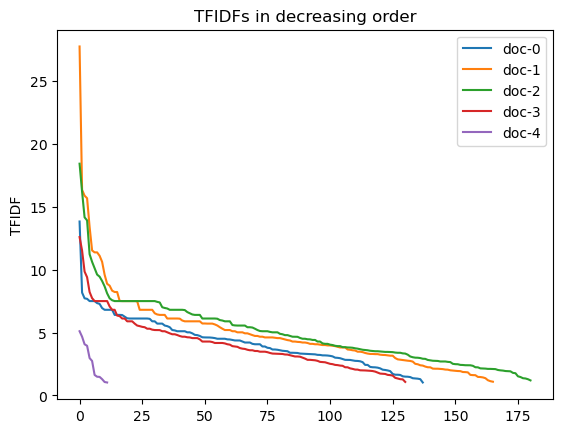

In [37]:
# calculate the TF and TF-IDF for each word in each document and subsequently decide to keep it or discard
for idx, document in enumerate(numerical_documents[0:5]):
    items, counts = np.unique(document, return_counts=True)
    TFIDFs = []
    for i in range(items.shape[0]):
        TFIDFs.append((items[i], counts[i]*IDFs[items[i]]+1))
    TFIDFs = sorted(TFIDFs, key=lambda x: x[1], reverse=True)
    print([index_to_word[i] for (i, score) in TFIDFs])
    plt.plot([score for (i, score) in TFIDFs], label=f'doc-{idx}')    
plt.ylabel('TFIDF')
plt.title('TFIDFs in decreasing order')
plt.legend()

In [7]:
# from the above it seems reasonable to retain at most 25 words for any given document
truncated_documents = []
for document in numerical_documents:
    items, counts = np.unique(document, return_counts=True)
    TFIDFs = []
    for i in range(items.shape[0]):
        TFIDFs.append((items[i], counts[i]*IDFs[items[i]]+1))
    TFIDFs = sorted(TFIDFs, key=lambda x: x[1], reverse=True)
    truncated_documents.append([idx for (idx, score) in TFIDFs[:min(len(TFIDFs), 25)]])   
for document in truncated_documents:
    print([index_to_word[i] for i in document])

['f', 'had', '+', 'features.', 'xn.', 'b2', 'illustration', 'things', 'y', 'dependent', 'suggests,', '...,', '......', 'b0,', 'earning,', 'b1,', 'corresponds', 'similar', 'statistically', 'started', 'age,', 'family', 'x3,', 'b1x1', 'raphson']
['encoding', 'textual', 'categorical', 'vectorization', 'numerical', 'target', 'encoding.', 'integer', 'one-hot', 'categories', 'binary', 'unique', 'techniques,', 'frequency', 'converting', 'meaningful', 'each', '(categories', 'order),', '(compact', 'columnsâ€”for', 'distinctions.', 'sessions.', 'category', 'initially,']
['î²o', ',', 'upon', 'gets', 'mean(y)', 'bias', 'statistic.', 'closer', 'level', 'sample', 'population', 'basis', 'sum', 'attributes', 'upon.', 'subtract.', 'parameter(s)', 'advt.', 'expenditure', 'y=î²o+î²1', 'unknown(unaccounted', 'for)', 'equate', 'y=ax', 'b=']
['layer', 'summaries', 'sine', 'added', 'degrees', 'layers', 'x1â²,x1â³,x1â\x81´.this', 'regression.from', 'p-value.then', 'model.however,', 'values.also,if', 'computati

Text(0.5, 1.0, 'Similarity Between Truncated Documents')

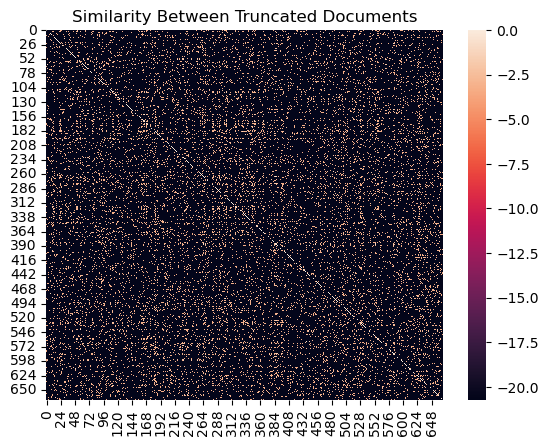

In [38]:
similarity = np.zeros((num_documents, num_documents))
for i, doc1 in enumerate(truncated_documents):
    for j, doc2 in enumerate(truncated_documents):
        count = 0
        for word in doc1:
            if word in doc2:
                count += 1
        similarity[i,j] = count/np.sqrt(len(doc1)*len(doc2))
        similarity[j, i] = count/np.sqrt(len(doc1)*len(doc2))
#for i in range(num_documents):
#    similarity[i, i] = 0
sns.heatmap(np.log(np.maximum(similarity, 1e-9)))
plt.title('Similarity Between Truncated Documents')

In [9]:
index = np.argmax(similarity)
i, j = np.unravel_index(index, (num_documents, num_documents))
print("DOCUMENT 1")
print(data.iloc[i]['Session_Summary'])
print("\nDOCUMENT 2")
print(data.iloc[j]['Session_Summary'])

DOCUMENT 1
we started by discussing the meaning of statistical significance. we discussed that if our value of beta lies within the 95% confidence interval, it means that our value depends on the sample we chose. if we chose another sample, the value could be different. so, we arrived at the conclusion that the value is not statistically significant; it is by chance. and if 0 is present in our interval, then beta can be zero by chance. however, if our value is outside that 95% interval, it means it is not by chanceâ€”it is statistically significant. for that, our p-value must be very low, allowing us to reject the null hypothesis that beta is zero. this applies to linear regression.

then we examined multiple linear regression (mlr), where we discussed different statistical parameters obtained using a spreadsheet. we analyzed the significance of each feature by looking at its coefficient. we also learned about f-statistics, which is the variance of error due to the regression model div

In [10]:
index = np.argsort(np.reshape(similarity, -1))[-20]
i, j = np.unravel_index(index, (num_documents, num_documents))
print("DOCUMENT 1")
print(data.iloc[i]['Session_Summary'])
print("\nDOCUMENT 2")
print(data.iloc[j]['Session_Summary'])

DOCUMENT 1
in  today's session, we focused on regression metrics, sampling distributions, and the central limit theorem (clt).we were also introduced to the idea that regression coefficients derived from sample data are estimates of population parameters, emphasizing the importance of evaluating their reliability.to understand this ,we examined the concept of sampling distributions, where multiple representative samples are drawn from a population to calculate sample means. these means tend to form a normal distribution as per the central limit theorem, regardless of the original population distribution, provided the sample size is sufficiently large. this principle allows statisticians to infer population characteristics and calculate confidence intervals for model parameters. we also saw metrics like sse (sum of squared errors), mse (mean squared error), rmse (root mean squared error), and mae (mean absolute error), which are necessary for analysing the performance of linear regressi

In [11]:
index = np.argsort(np.reshape(similarity, -1))[-30]
i, j = np.unravel_index(index, (num_documents, num_documents))
print("DOCUMENT 1")
print(data.iloc[i]['Session_Summary'])
print("\nDOCUMENT 2")
print(data.iloc[j]['Session_Summary'])

DOCUMENT 1
we learned about the metrics used to check how good a linear regression model is, like sse,râ²,etc. 
we also have a hands on excel .
the data we use is just a sample , so the values we calculate for the model, like a and b, are only guesses about the real values for the entire population.
goal  is to create a model that works well for data outside the sample.
idea of sampling distributions and confidence intervals. if we take many small samples from the population and find their means, those means would form a normal distribution, even if the population data isnâ€™t normally distributed. this is called the central limit theorem (clt). the bigger samples give more accurate results, while smaller samples create more uncertainty. 

DOCUMENT 2
today in class, sir talked about the metrics we use to check how good a linear regression model is, like sse,râ²,etc. he said that when we use tools like excel, many more numbers appear, and to understand them, we need to go back to basic 

'''now we try to implement word2vec on our summaries
TF-IDF is useful for identifying important words in a document, but it doesn’t understand the meaning.
Word2Vec generates vector representations of words in such a way that semantically similar words are close in the vector space.
So even if two summaries use different vocabulary but convey similar content, Word2Vec can capture that — unlike TF-IDF.
'''

In [13]:
#import necessary modules
from gensim.models import Word2Vec

In [71]:
#model creation using CBOW 
model = Word2Vec(
    sentences=documents,     # list of lists of tokens
    vector_size=25,         # size of the embedding vectors (hidden layer size)
    window=5,                # context window: how many words left and right to consider
    min_count=2,             # ignore words with total frequency < 2
    sg=0,                    # sg=0 means CBOW; sg=1 means Skip-gram
    workers=4,               # number of CPU cores for parallelization
    epochs=20                # how many times to iterate over the corpus
)


In [72]:
model.wv.similarity('science', 'learning')  # Cosine similarity

0.41860512

In [73]:
model.wv.most_similar('mlr', topn=10)


[('slr', 0.8452044725418091),
 ('regression.', 0.845035195350647),
 ('multiple', 0.803927481174469),
 ('solution', 0.7950150370597839),
 ('expressed', 0.77960604429245),
 ('closed', 0.7740620374679565),
 ('simple', 0.7728662490844727),
 ('closed-form', 0.7724663615226746),
 ('polynomial', 0.7521963119506836),
 ('regression', 0.7483679056167603)]

In [74]:
#represeting a document( one summary) as a single vector of mean of all word embeddings

def document_embedding(doc, model):
    valid_vectors = [model.wv[word] for word in doc if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

doc_vectors = np.array([document_embedding(doc, model) for doc in documents])

In [75]:
#printing 2 doc_vectors
doc_vectors[6]

array([-0.23286828,  0.05576599,  0.59612721,  0.25130531, -0.51222241,
       -0.12593566,  0.20787041,  0.51948035, -1.19559407, -0.68223476,
        0.33734909, -0.07383537,  0.52830654,  1.07251072,  0.20293254,
        0.43416229,  0.78645539, -0.45270097, -0.08673178,  0.10577932,
       -0.14340511, -0.25447375,  0.3487891 ,  0.43749401,  0.898467  ])

In [76]:
#finding cosine similarity for doc_vectors(no TFIDF)
from sklearn.metrics.pairwise import cosine_similarity
# Convert to numpy array (shape: num_documents x vector_dim)
embedding_matrix = np.array(doc_vectors)

# Compute pairwise cosine similarity
similarity_matrix = cosine_similarity(embedding_matrix)

# Set self-similarity to zero (to ignore identical docs)
np.fill_diagonal(similarity_matrix, 0)

In [77]:
# Top 1 most similar pair
index = np.argmax(similarity_matrix)
i, j = np.unravel_index(index, similarity_matrix.shape)
print("✅ MOST SIMILAR PAIR")
print("\nDOCUMENT 1:\n", data.iloc[i]['Session_Summary'])
print("\nDOCUMENT 2:\n", data.iloc[j]['Session_Summary'])

✅ MOST SIMILAR PAIR

DOCUMENT 1:
 we started by discussing the meaning of statistical significance. we discussed that if our value of beta lies within the 95% confidence interval, it means that our value depends on the sample we chose. if we chose another sample, the value could be different. so, we arrived at the conclusion that the value is not statistically significant; it is by chance. and if 0 is present in our interval, then beta can be zero by chance. however, if our value is outside that 95% interval, it means it is not by chanceâ€”it is statistically significant. for that, our p-value must be very low, allowing us to reject the null hypothesis that beta is zero. this applies to linear regression.

then we examined multiple linear regression (mlr), where we discussed different statistical parameters obtained using a spreadsheet. we analyzed the significance of each feature by looking at its coefficient. we also learned about f-statistics, which is the variance of error due to t

In [78]:
# 10th most similar pair
index_10 = np.argsort(similarity_matrix.ravel())[-10]
i10, j10 = np.unravel_index(index_10, similarity_matrix.shape)
print("\n✅ 10TH MOST SIMILAR PAIR")
print("\nDOCUMENT 1:\n", data.iloc[i10]['Session_Summary'])
print("\nDOCUMENT 2:\n", data.iloc[j10]['Session_Summary'])


✅ 10TH MOST SIMILAR PAIR

DOCUMENT 1:
 learnt about population and sample.if not impossible then it will be very expensive to work with the data of entire population so we always study some parts of the population i.e. sample.our main objective is to estimate different parameters of the population based on the statistics that we obtained from our sample. there are various attributes associated to a data.for example if we have the data of marbles in the box then we can calculate frequency of particular colour balls,mean,median,mode,standard deviation,variance and also can perform certain operations like addition, subtraction,etc.we use different models like line,point depending on the data we have.point is considered a very naive model.
then took an example of simple linear regression(assuming only one predictor i.e. advertisement expenditure) to predict sales.for that the equation is y=b_0+b_1x where b_0 and b_1 of sample are point estimates of population parameters i e. we can claim 

'''
Now we will try to incorporate TFIDF scores based weighted average to reprsent a summary
we add weights using IDF values of the words to top 25 tfidf words_embedding vectors while taking mean 
'''

In [79]:
#convering truncated doc to words
word_docs = [[index_to_word[i] for i in doc] for doc in truncated_documents]


In [80]:
#IDF normalized
idf_values = np.array(list(IDFs.values()))
idf_min, idf_max = idf_values.min(), idf_values.max()

def normalize_idf(x):
    return (x - idf_min) / (idf_max - idf_min + 1e-9)

In [81]:
#doc_embeddings contain summaries as vector
doc_embeddings = []
for doc in word_docs:
    vectors = []
    weights = []
    for word in doc:
        if word in model.wv:
            vec = model.wv[word]
            vectors.append(vec)
            weights.append(normalize_idf(IDFs[word_to_index[word]]))  # TF-IDF weight
    if vectors:
        vectors = np.array(vectors)
        weights = np.array(weights)
        weighted_avg = np.average(vectors, axis=0, weights=weights)
        doc_embeddings.append(weighted_avg)

In [26]:
#printed few summary vectors
doc_embeddings[:2]

[array([-0.11317359,  0.07439431,  0.1881364 ,  0.06056896,  0.05742447,
        -0.07544828,  0.19408302,  0.34684749, -0.10825494, -0.01371389,
        -0.08228452, -0.26570398, -0.04978391,  0.07323866,  0.28208877,
        -0.26482876, -0.00729051, -0.3589712 , -0.0271569 , -0.21584054,
         0.23324676,  0.11130816, -0.00714469, -0.01345724,  0.2007009 ,
         0.0142327 , -0.06973714,  0.17190353, -0.06872634, -0.00084717,
         0.00162811,  0.12510687, -0.27465763, -0.11705975, -0.00064738,
        -0.0091727 ,  0.25246305, -0.17320927, -0.0877497 , -0.25768791,
        -0.08134559, -0.13172717, -0.01157142, -0.00278889,  0.00738259,
        -0.07479498,  0.0328919 , -0.10561132, -0.16994397,  0.16003026,
         0.10941417, -0.22539204, -0.13640228, -0.02139327, -0.13173391,
        -0.06919201,  0.12369566,  0.06424837, -0.20837546,  0.27543951,
         0.04836713, -0.16421203,  0.1367032 , -0.22219289, -0.10713131,
         0.1629538 , -0.06297446,  0.1065607 , -0.3

In [27]:
#finding cosine similarity for doc_vectors(using TFIDF)
from sklearn.metrics.pairwise import cosine_similarity
# Convert to numpy array (shape: num_documents x vector_dim)
embedding_matrix1 = np.array(doc_embeddings)

# Compute pairwise cosine similarity
similarity_matrix1 = cosine_similarity(embedding_matrix1)

# Set self-similarity to zero (to ignore identical docs)
np.fill_diagonal(similarity_matrix1, 0)

In [28]:
# Top 1 most similar pair
index = np.argmax(similarity_matrix1)
i, j = np.unravel_index(index, similarity_matrix1.shape)
print("✅ MOST SIMILAR PAIR")
print("\nDOCUMENT 1:\n", data.iloc[i]['Session_Summary'])
print("\nDOCUMENT 2:\n", data.iloc[j]['Session_Summary'])

✅ MOST SIMILAR PAIR

DOCUMENT 1:
 we began by reading through the summaries and looking at the trends in the data. from the graph, we observed that as the sessions progressed, fewer people were submitting summaries, but the average word count in each summary was increasing. then, we looked at a case where the function was like a sine curve. we started with a single feature, x1. then, we produced additional features like x1^2, x1^3, x1^4 with polynomial regression. this allowed us to calculate a p-value. to enhance the model, we added another feature, sin(x1), and found that the new p-value calculated was smaller than before, so this sine-based feature was adding to some extent. although addition of too many features beyond a certain point may reduce the model's effectiveness, this is reflected in a drop in the adjusted r^2 value. as long as a single model can capture the data well, it is always better than using multiple models unnecessarily. we also covered some significant parametric

In [29]:
# 10th most similar pair
index_10 = np.argsort(similarity_matrix1.ravel())[-10]
i10, j10 = np.unravel_index(index_10, similarity_matrix1.shape)
print("\n✅ 10TH MOST SIMILAR PAIR")
print("\nDOCUMENT 1:\n", data.iloc[i10]['Session_Summary'])
print("\nDOCUMENT 2:\n", data.iloc[j10]['Session_Summary'])


✅ 10TH MOST SIMILAR PAIR

DOCUMENT 1:
 in the lecture we learned about nominal, interval, ratio scales and how are they used in the field of data science. we also learned briefly about supervised and unsupervised learnings i.e. if the data is labelled or unlabelled. the prof also discussed about various ml models and telling their types and uses accordingly in a brief manner.

DOCUMENT 2:
 today's class covered forward and backward feature selection. forward selection adds features one by one, while backward selection removes the least important ones, both aiming to improve model performance. we also discussed and compared machine learning models including random forest, knn, artificial neural networks, xgboost, etc. 
also that the life of a data scientist includes spending time with numbers, models, and comparisons. we also discussed what a neural network is: a model made up of layers of nodes (neurons), including input, hidden, and output layers, where hidden layers help detect patt

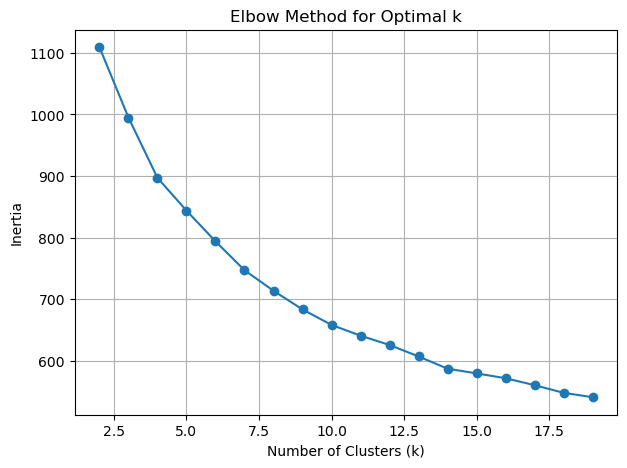

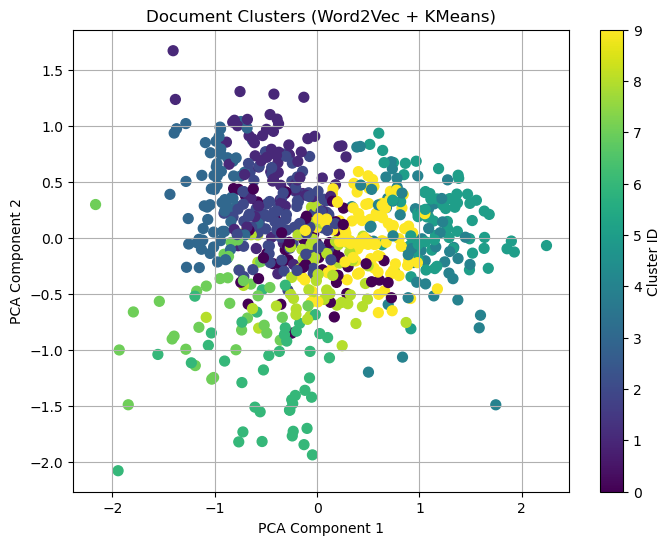


--- Cluster 0 ---
https://docs.google.com/forms/d/e/1faipqlsffcpe8ytvk7pee7cslz0xgjhjk3_a8y7jo1abmkldxnrim4a/closedform
------------------------------------------------------------
to improve the likelihood of accurate predictions, logistic regression is used to generate weighted values. we maximize p if t=1 and if t=0 we maximize 1-p. because working with product terms can be complex, it is necessary to utilize a logarithm to simplify computations by converting them into summations. we evaluate model performance using a confusion matrix consisting of true negatives, false positives, false negatives, and true positives. important measures include accuracy , precision and recall (the model's capacity to identify all actual positive examples).the f1 score is a harmonic mean of precision and recall, a balanced statistic that doesnt burden off accuracy alone.
------------------------------------------------------------
in today's class, we started with the discussion on metrics which dete

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---------- Step 1: Create Document Vectors (Word2Vec-based) ----------
def document_embedding(doc, model):
    valid_vectors = [model.wv[word] for word in doc if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

doc_vectors = np.array([document_embedding(doc, model) for doc in documents])

# ---------- Step 2: Elbow Method to Find Optimal k ----------
inertias = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(doc_vectors)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# ---------- Step 3: Run KMeans with Optimal k ----------
optimal_k = 10  # Adjust this based on your elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(doc_vectors)

# ---------- Step 4: Visualize Clusters in 2D using PCA ----------
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(doc_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Document Clusters (Word2Vec + KMeans)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.show()

# ---------- Step 5: Inspect Documents in Each Cluster ----------
for cluster_id in range(optimal_k):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0]
    for i in indices[:3]:  # show first 3 summaries per cluster
        print(data.iloc[i]['Session_Summary'])
        print("-" * 60)

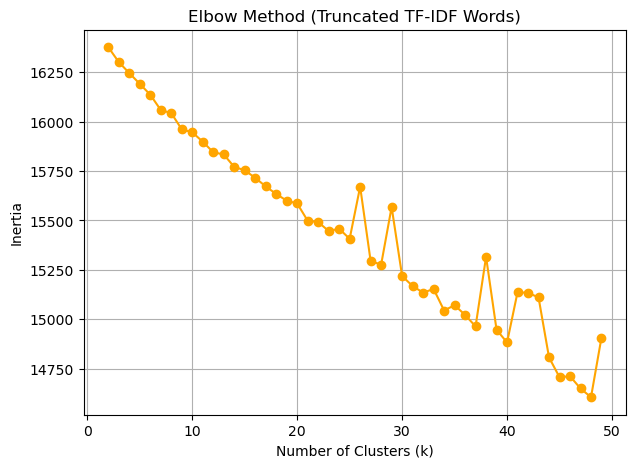

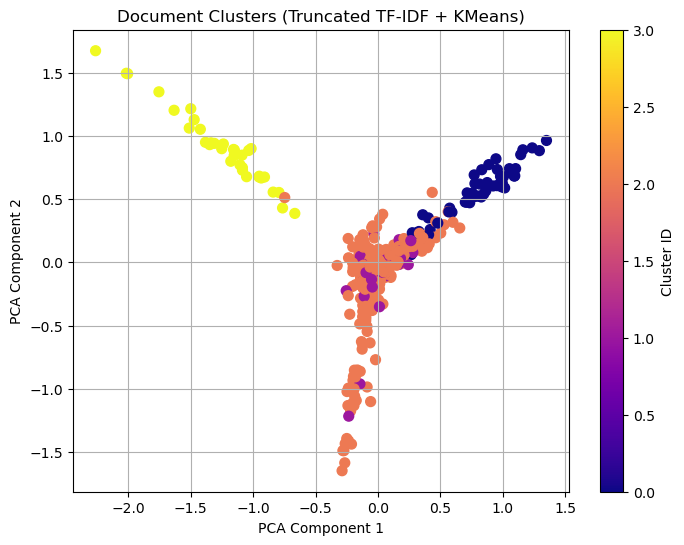


--- Cluster 0 (Truncated TF-IDF) ---
population and sample were further discussed upon. sample is a good and representative part of the population. sample is used to predict/estimate the population. attributes and operations such as count, mode , median, mean, std. deviation , variance , add, multiply, divide and subtract. different level of measurement were classified on the basis of these attributes and operations. population has parameter(s) while sample has statistic. we estimate parameters on the basis of these statistic. linear data model was discussed upon from the sales vs advt. expenditure . any model can be fitted upon any set of data but it might not be the best fit. even a point can be considered a model although a naive model. as sample size increases the estimation of parameters gets better and better. based on th sample a slr can be fit with the equation y=î²o+î²1 , where î²o is the bias in the data , as the sample size gets closer and closer to the population this bias

In [56]:
from sklearn.preprocessing import MultiLabelBinarizer


# ---------- Now: Clustering on Truncated Documents (Top TF-IDF words) ----------
# Convert truncated_documents (lists of word indices) to binary vectors
mlb = MultiLabelBinarizer()
binary_doc_matrix = mlb.fit_transform(truncated_documents)  # shape: [num_docs x vocab_subset_size]

# ---------- Elbow Method (Truncated) ----------
inertias_trunc = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(binary_doc_matrix)
    inertias_trunc.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, inertias_trunc, marker='o', color='orange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Truncated TF-IDF Words)")
plt.grid(True)
plt.show()

# ---------- KMeans Clustering (Truncated TF-IDF) ----------
optimal_k_trunc = 4  # Adjust based on elbow
kmeans_trunc = KMeans(n_clusters=optimal_k_trunc, random_state=42, n_init=10)
labels_trunc = kmeans_trunc.fit_predict(binary_doc_matrix)

# ---------- PCA Visualization (Truncated) ----------
pca_trunc = PCA(n_components=2)
reduced_trunc = pca_trunc.fit_transform(binary_doc_matrix)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_trunc[:, 0], reduced_trunc[:, 1], c=labels_trunc, cmap='plasma', s=50)
plt.title("Document Clusters (Truncated TF-IDF + KMeans)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.show()

# ---------- View Truncated TF-IDF Clusters ----------
for cluster_id in range(optimal_k_trunc):
    print(f"\n--- Cluster {cluster_id} (Truncated TF-IDF) ---")
    indices = np.where(labels_trunc == cluster_id)[0]
    for i in indices[:3]:
        print(data.iloc[i]['Session_Summary'])
        print("-" * 60)

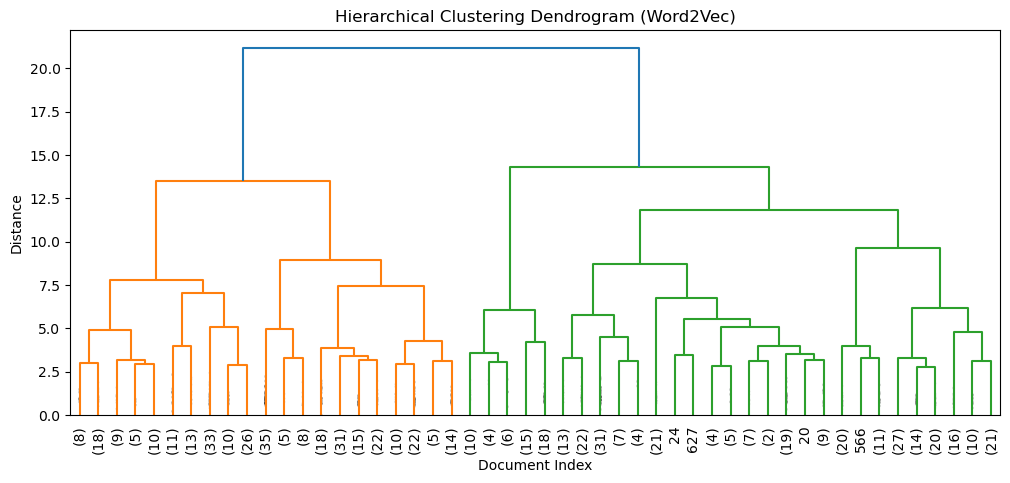

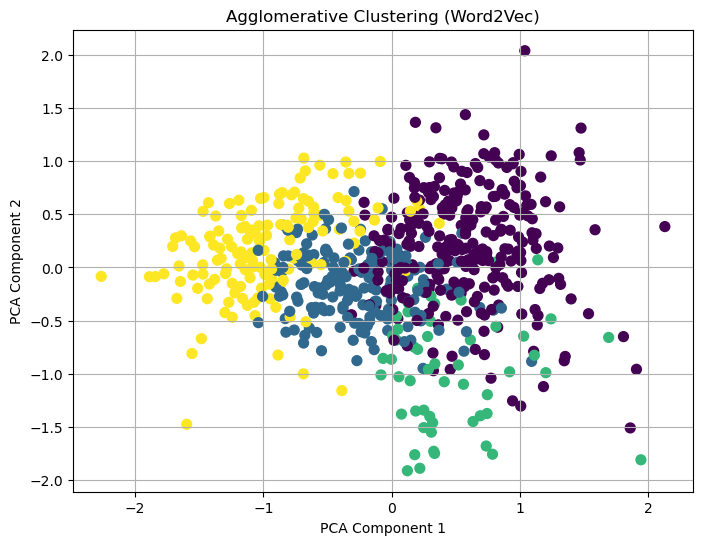

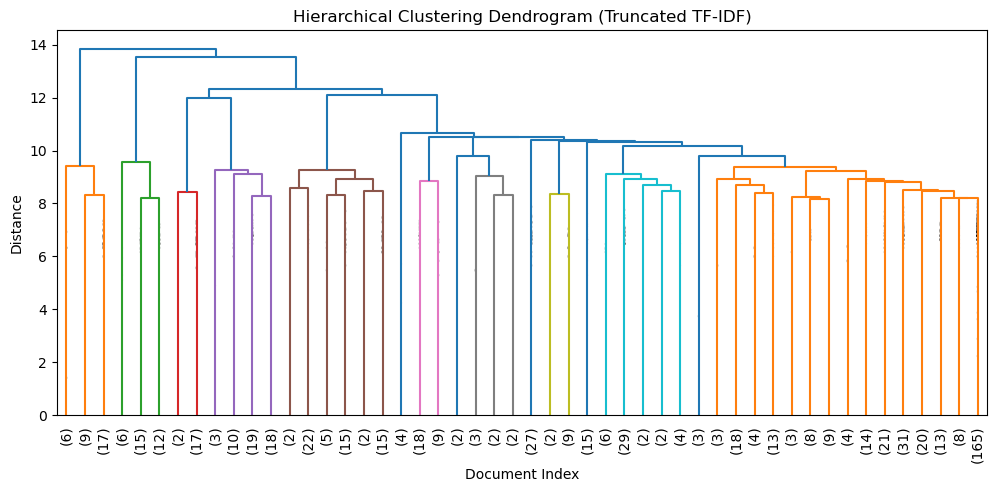

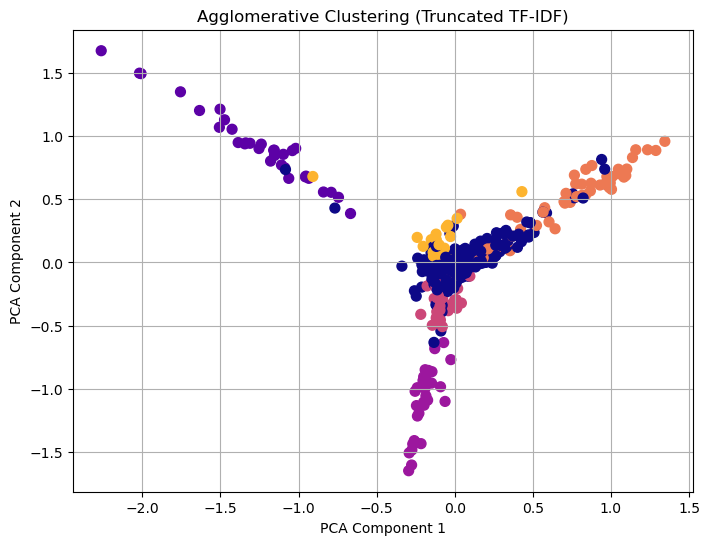


📂 Word2Vec-Based Clusters:

--- Cluster 0 ---
in this session, we explored various feature encoding techniques, essential for converting categorical and textual data into numerical representations suitable for machine learning models. initially, we discussed vectorization and one-hot encoding. vectorization is a general approach to transform textual or categorical data into numerical vectors. one-hot encoding specifically converts categorical variables into binary vectors, creating separate columns for each category. this method is widely used in multiclass and multilabel classification problems but can introduce the curse of dimensionality when dealing with variables having many unique categories.

we then examined label encoding and integer encoding. label encoding assigns each categorical class a unique integer value. while this method is straightforward, it implies an ordinal relationship between categories, which may not always be appropriate. integer encoding is particularly use

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MultiLabelBinarizer

# --- Word2Vec-Based Hierarchical Clustering ---

# 1. Perform linkage for dendrogram
linkage_matrix_w2v = linkage(doc_vectors, method='ward')

# 2. Plot dendrogram (Word2Vec)
plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix_w2v, truncate_mode='lastp', p=50, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Word2Vec)")
plt.xlabel("Document Index")
plt.ylabel("Distance")
plt.show()

# 3. Agglomerative Clustering (Word2Vec)
num_clusters_w2v = 4  # You can decide from dendrogram
agglo_w2v = AgglomerativeClustering(n_clusters=num_clusters_w2v, metric='euclidean', linkage='ward')
labels_w2v = agglo_w2v.fit_predict(doc_vectors)

# 4. PCA Visualization (Word2Vec)
pca = PCA(n_components=7)
reduced_w2v = pca.fit_transform(doc_vectors)
plt.figure(figsize=(8, 6))
plt.scatter(reduced_w2v[:, 0], reduced_w2v[:, 1], c=labels_w2v, cmap='viridis', s=50)
plt.title("Agglomerative Clustering (Word2Vec)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

# --- Truncated TF-IDF Word Indices Hierarchical Clustering ---

# 1. Convert truncated docs to binary vectors
mlb = MultiLabelBinarizer()
binary_doc_matrix = mlb.fit_transform(truncated_documents)

# 2. Linkage and dendrogram (Truncated)
linkage_matrix_trunc = linkage(binary_doc_matrix, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix_trunc, truncate_mode='lastp', p=50, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Truncated TF-IDF)")
plt.xlabel("Document Index")
plt.ylabel("Distance")
plt.show()

# 3. Agglomerative Clustering (Truncated)
num_clusters_trunc = 7  # Choose based on dendrogram
agglo_trunc = AgglomerativeClustering(n_clusters=num_clusters_trunc, metric='euclidean', linkage='ward')
labels_trunc = agglo_trunc.fit_predict(binary_doc_matrix)

# 4. PCA Visualization (Truncated)
pca_trunc = PCA(n_components=2)
reduced_trunc = pca_trunc.fit_transform(binary_doc_matrix)
plt.figure(figsize=(8, 6))
plt.scatter(reduced_trunc[:, 0], reduced_trunc[:, 1], c=labels_trunc, cmap='plasma', s=50)
plt.title("Agglomerative Clustering (Truncated TF-IDF)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

# --- Show Sample Documents from Each Cluster ---

print("\n📂 Word2Vec-Based Clusters:")
for cluster_id in range(num_clusters_w2v):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels_w2v == cluster_id)[0]
    for i in indices[:3]:  # Show top 3 per cluster
        print(data.iloc[i]['Session_Summary'])
        print("-" * 60)

print("\n📂 Truncated TF-IDF-Based Clusters:")
for cluster_id in range(num_clusters_trunc):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels_trunc == cluster_id)[0]
    for i in indices[:3]:
        print(data.iloc[i]['Session_Summary'])
        print("-" * 60)

/Applications/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


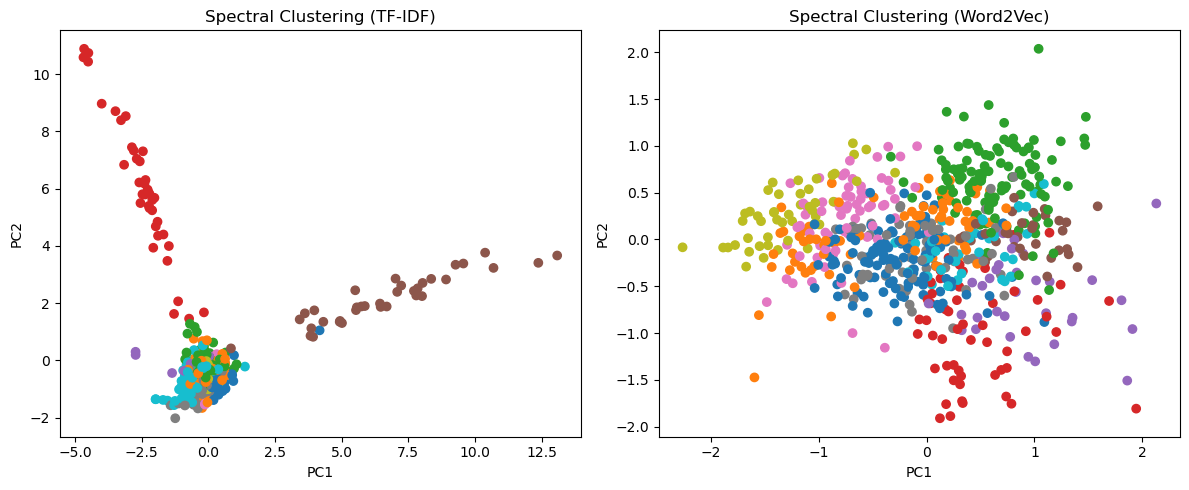

In [65]:
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# === 1. Convert truncated_documents to binary matrix (TF-IDF weighted optional) ===
vocab_size = len(index_to_word)
binary_doc_matrix = np.zeros((num_documents, vocab_size))

for i, doc in enumerate(truncated_documents):
    for word_idx in doc:
        binary_doc_matrix[i, word_idx] = IDFs[word_idx] + 1  # You can just set 1 for pure binary

# === 2. PCA reduction for TF-IDF ===
pca_tfidf = PCA(n_components=2)
pca_docs_tfidf = pca_tfidf.fit_transform(binary_doc_matrix)

# === 3. PCA reduction for Word2Vec ===
pca_w2v = PCA(n_components=2)
pca_docs_w2v = pca_w2v.fit_transform(doc_vectors)

# === 4. Spectral Clustering ===
n_clusters = 10

# -- TF-IDF Based --
similarity_matrix = cosine_similarity(binary_doc_matrix)
spectral_tfidf = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
labels_tfidf = spectral_tfidf.fit_predict(similarity_matrix)

# -- Word2Vec Based --
spectral_w2v = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
labels_w2v = spectral_w2v.fit_predict(doc_vectors)

# === 5. Visualize ===
plt.figure(figsize=(12, 5))

# -- TF-IDF Plot --
plt.subplot(1, 2, 1)
plt.scatter(pca_docs_tfidf[:, 0], pca_docs_tfidf[:, 1], c=labels_tfidf, cmap='tab10')
plt.title("Spectral Clustering (TF-IDF)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# -- Word2Vec Plot --
plt.subplot(1, 2, 2)
plt.scatter(pca_docs_w2v[:, 0], pca_docs_w2v[:, 1], c=labels_w2v, cmap='tab10')
plt.title("Spectral Clustering (Word2Vec)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

/Applications/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


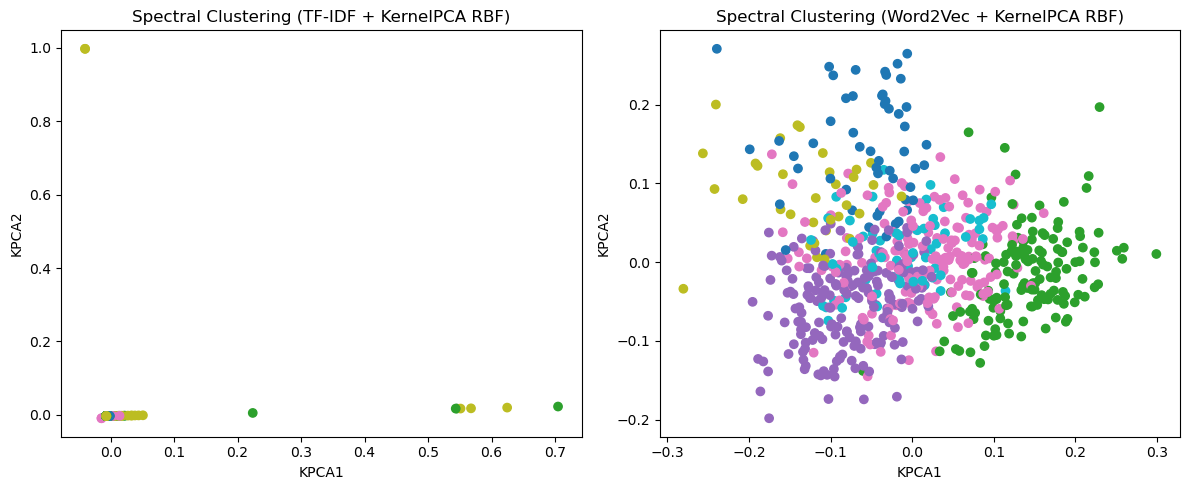

In [83]:
from sklearn.decomposition import KernelPCA
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# === 1. Convert truncated_documents to binary matrix (TF-IDF weighted optional) ===
vocab_size = len(index_to_word)
binary_doc_matrix = np.zeros((num_documents, vocab_size))

for i, doc in enumerate(truncated_documents):
    for word_idx in doc:
        binary_doc_matrix[i, word_idx] = IDFs[word_idx] + 1  # or just 1 for binary

# === 2. Kernel PCA with RBF kernel for TF-IDF ===
kpca_tfidf = KernelPCA(n_components=2, kernel='rbf', gamma=0.01)  # Adjust gamma as needed
kpca_docs_tfidf = kpca_tfidf.fit_transform(binary_doc_matrix)

# === 3. Kernel PCA with RBF kernel for Word2Vec ===
kpca_w2v = KernelPCA(n_components=2, kernel='rbf', gamma=0.01)
kpca_docs_w2v = kpca_w2v.fit_transform(doc_vectors)

# === 4. Spectral Clustering ===
n_clusters = 6

# -- TF-IDF Based --
similarity_matrix = cosine_similarity(binary_doc_matrix)
spectral_tfidf = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
labels_tfidf = spectral_tfidf.fit_predict(similarity_matrix)

# -- Word2Vec Based --
spectral_w2v = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
labels_w2v = spectral_w2v.fit_predict(doc_vectors)

# === 5. Visualize ===
plt.figure(figsize=(12, 5))

# -- TF-IDF Plot --
plt.subplot(1, 2, 1)
plt.scatter(kpca_docs_tfidf[:, 0], kpca_docs_tfidf[:, 1], c=labels_tfidf, cmap='tab10')
plt.title("Spectral Clustering (TF-IDF + KernelPCA RBF)")
plt.xlabel("KPCA1")
plt.ylabel("KPCA2")

# -- Word2Vec Plot --
plt.subplot(1, 2, 2)
plt.scatter(kpca_docs_w2v[:, 0], kpca_docs_w2v[:, 1], c=labels_w2v, cmap='tab10')
plt.title("Spectral Clustering (Word2Vec + KernelPCA RBF)")
plt.xlabel("KPCA1")
plt.ylabel("KPCA2")

plt.tight_layout()
plt.show()

Epoch 1/30, Loss: 10.7403
Epoch 2/30, Loss: 10.1094
Epoch 3/30, Loss: 9.5491
Epoch 4/30, Loss: 8.2929
Epoch 5/30, Loss: 7.3351
Epoch 6/30, Loss: 6.5199
Epoch 7/30, Loss: 5.7374
Epoch 8/30, Loss: 5.0373
Epoch 9/30, Loss: 4.6745
Epoch 10/30, Loss: 4.3761
Epoch 11/30, Loss: 4.0512
Epoch 12/30, Loss: 3.7560
Epoch 13/30, Loss: 3.5393
Epoch 14/30, Loss: 3.2419
Epoch 15/30, Loss: 3.0350
Epoch 16/30, Loss: 2.7766
Epoch 17/30, Loss: 2.5670
Epoch 18/30, Loss: 2.4425
Epoch 19/30, Loss: 2.3251
Epoch 20/30, Loss: 2.2069
Epoch 21/30, Loss: 2.1381
Epoch 22/30, Loss: 2.0501
Epoch 23/30, Loss: 1.9631
Epoch 24/30, Loss: 1.9228
Epoch 25/30, Loss: 1.8256
Epoch 26/30, Loss: 1.8325
Epoch 27/30, Loss: 1.7025
Epoch 28/30, Loss: 1.6596
Epoch 29/30, Loss: 1.6168
Epoch 30/30, Loss: 1.5664


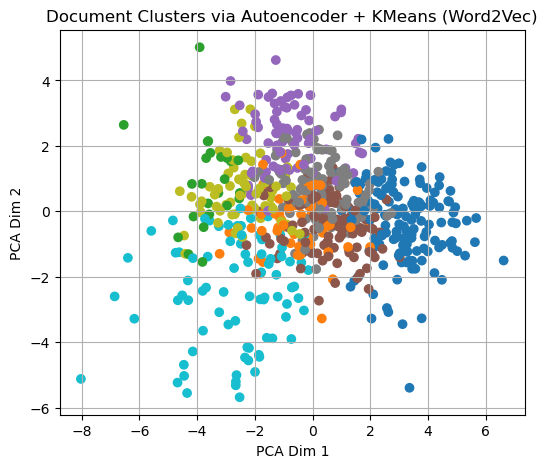

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# === 1. Use Word2Vec Document Vectors ===
input_data = doc_vectors  # Should be shape [num_documents, embedding_dim]
n_clusters = 8

# Normalize input
scaler = StandardScaler()
input_data = scaler.fit_transform(input_data)

# Convert to PyTorch tensor
X_tensor = torch.tensor(input_data, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# === 2. Autoencoder Definition ===
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# === 3. Training Autoencoder ===
input_dim = input_data.shape[1]
latent_dim = 10

model = Autoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

num_epochs = 30
train_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()
        x_hat = model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

# === 4. Get Latent Representations ===
with torch.no_grad():
    latent_embeddings = model.encoder(X_tensor).numpy()

# === 5. KMeans Clustering on Latent Space ===
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(latent_embeddings)

# === 6. 2D PCA Visualization ===
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
plot_embeds = pca.fit_transform(latent_embeddings)

plt.figure(figsize=(6, 5))
plt.scatter(plot_embeds[:, 0], plot_embeds[:, 1], c=labels, cmap='tab10')
plt.title("Document Clusters via Autoencoder + KMeans (Word2Vec)")
plt.xlabel("PCA Dim 1")
plt.ylabel("PCA Dim 2")
plt.grid(True)
plt.show()